<a href="https://colab.research.google.com/github/deepaknathcg/HEARTATTACK_PREDICTION/blob/main/patientsdata1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **problem** **statements**
With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/Patients Data ( Used for Heart Disease Prediction ).csv", encoding='latin1', on_bad_lines='skip', engine='python')
df

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208740,208741,Washington,Male,Excellent,Age 80 or older,1.85,90.720001,26.389999,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",1,0,1,1,"Yes, received tetanus shot, but not Tdap",0,0
208741,208742,Washington,Female,Very good,Age 80 or older,1.60,65.769997,25.690001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"No, did not receive any tetanus shot in the pa...",0,0
208742,208743,Washington,Male,Very good,Age 50 to 54,1.83,79.379997,23.730000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,1,0,0,"Yes, received Tdap",0,0
208743,208744,Washington,Male,Excellent,Age 25 to 29,1.80,81.650002,25.100000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,1,1,1,"Yes, received Tdap",0,0


In [ ]:
df.tail()

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
208740,208741,Washington,Male,Excellent,Age 80 or older,1.85,90.720001,26.389999,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",1,0,1,1,"Yes, received tetanus shot, but not Tdap",0,0
208741,208742,Washington,Female,Very good,Age 80 or older,1.60,65.769997,25.690001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"No, did not receive any tetanus shot in the pa...",0,0
208742,208743,Washington,Male,Very good,Age 50 to 54,1.83,79.379997,23.730000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,1,0,0,"Yes, received Tdap",0,0
208743,208744,Washington,Male,Excellent,Age 25 to 29,1.80,81.650002,25.100000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,1,1,1,"Yes, received Tdap",0,0
208744,208745,Washington,Female,Very good,Age 35 to 39,1.70,80.739998,27.879999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,0,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208745 entries, 0 to 208744
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 208745 non-null  int64  
 1   State                      208745 non-null  object 
 2   Sex                        208745 non-null  object 
 3   GeneralHealth              208745 non-null  object 
 4   AgeCategory                208745 non-null  object 
 5   HeightInMeters             208745 non-null  float64
 6   WeightInKilograms          208745 non-null  float64
 7   BMI                        208745 non-null  float64
 8   HadHeartAttack             208745 non-null  int64  
 9   HadAngina                  208745 non-null  int64  
 10  HadStroke                  208745 non-null  int64  
 11  HadAsthma                  208745 non-null  int64  
 12  HadSkinCancer              208745 non-null  int64  
 13  HadCOPD                    20

In [ ]:
df.isnull().sum()

,0
ÿPatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# visualisation

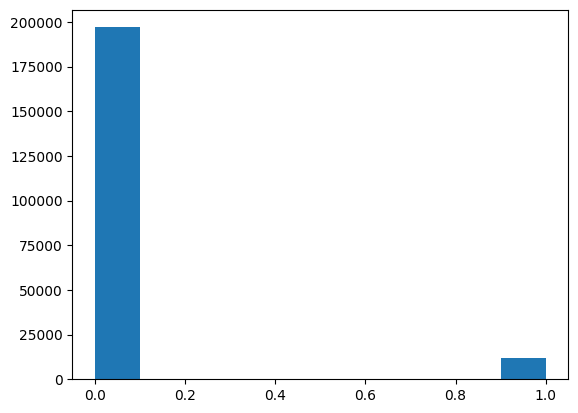

In [ ]:
plt.hist(df["HadHeartAttack"])
plt.show()

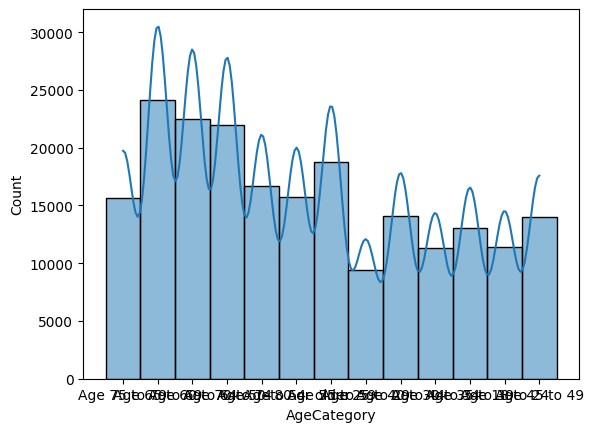

In [ ]:
sns.histplot(df['AgeCategory'],kde=True)
plt.show()

<Axes: xlabel='Sex', ylabel='count'>

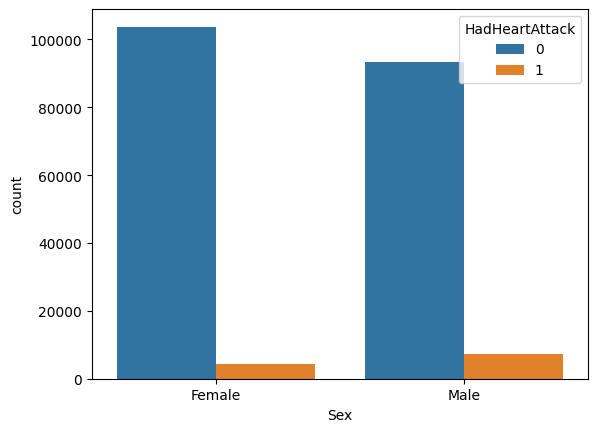

In [ ]:
sns.countplot(data=df,x='Sex',hue='HadHeartAttack')

<Axes: xlabel='GeneralHealth', ylabel='count'>

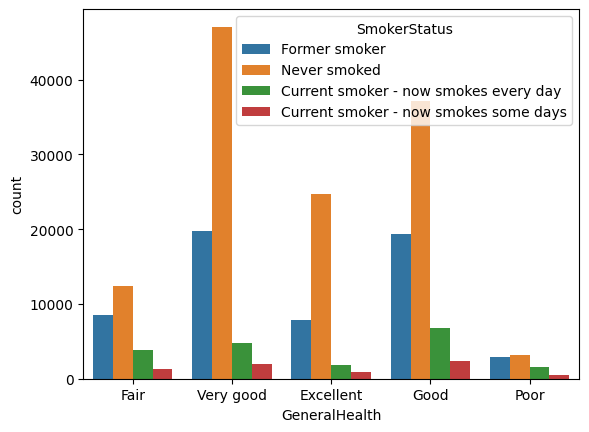

In [ ]:
sns.countplot(data=df,x='GeneralHealth',hue='SmokerStatus')

# correlation analysis

In [ ]:
df.head()

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208745 entries, 0 to 208744
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 208745 non-null  int64  
 1   State                      208745 non-null  object 
 2   Sex                        208745 non-null  object 
 3   GeneralHealth              208745 non-null  object 
 4   AgeCategory                208745 non-null  object 
 5   HeightInMeters             208745 non-null  float64
 6   WeightInKilograms          208745 non-null  float64
 7   BMI                        208745 non-null  float64
 8   HadHeartAttack             208745 non-null  int64  
 9   HadAngina                  208745 non-null  int64  
 10  HadStroke                  208745 non-null  int64  
 11  HadAsthma                  208745 non-null  int64  
 12  HadSkinCancer              208745 non-null  int64  
 13  HadCOPD                    20

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['State']=le.fit_transform(df['State'])
df['Sex']=le.fit_transform(df['Sex'])
df['AgeCategory']=le.fit_transform(df['AgeCategory'])
df['HadDiabetes']=le.fit_transform(df['HadDiabetes'])
df['SmokerStatus']=le.fit_transform(df['SmokerStatus'])
df['RaceEthnicityCategory']=le.fit_transform(df['RaceEthnicityCategory'])
df['TetanusLast10Tdap']=le.fit_transform(df['TetanusLast10Tdap'])

In [ ]:
print(df['GeneralHealth'].unique())

['Fair' 'Very good' 'Excellent' 'Good' 'Poor']


In [ ]:
df["ECigaretteUsage"].replace(['Never used e-cigarettes in my entire life','Not at all (right now)','Use them some days','Use them every day'],[0,1,2,3],inplace=True)

/tmp/ipykernel_39931/3037838442.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ECigaretteUsage"].replace(['Never used e-cigarettes in my entire life','Not at all (right now)','Use them some days','Use them every day'],[0,1,2,3],inplace=True)
/tmp/ipykernel_39931/3037838442.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('futur

In [ ]:
df["GeneralHealth"].replace(['Fair','Very good','Excellent','Good','Poor'],[0,1,2,3,4],inplace=True)

/tmp/ipykernel_39931/2259057251.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["GeneralHealth"].replace(['Fair','Very good','Excellent','Good','Poor'],[0,1,2,3,4],inplace=True)
/tmp/ipykernel_39931/2259057251.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["GeneralHealth"].replace(['F

In [ ]:
df

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,0,0,0,11,1.63,84.820000,32.099998,0,1,...,0,1,4,0,0,0,1,0,0,1
1,2,0,0,1,9,1.60,71.669998,27.990000,0,0,...,0,0,4,0,0,1,1,1,0,0
2,3,0,1,2,8,1.78,71.209999,22.530001,0,0,...,0,0,4,1,0,0,0,2,0,0
3,4,0,1,1,10,1.78,95.250000,30.129999,0,0,...,0,0,4,0,0,1,1,2,0,0
4,5,0,0,3,6,1.68,78.019997,27.760000,0,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208740,208741,47,1,2,12,1.85,90.720001,26.389999,0,1,...,0,1,4,1,0,1,1,3,0,0
208741,208742,47,0,1,12,1.60,65.769997,25.690001,0,0,...,0,0,4,0,0,1,1,0,0,0
208742,208743,47,1,1,6,1.83,79.379997,23.730000,0,0,...,0,0,4,1,1,0,0,1,0,0
208743,208744,47,1,2,1,1.80,81.650002,25.100000,0,0,...,0,0,4,1,1,1,1,1,0,0


In [ ]:
from imblearn.over_sampling import SMOTE

x=df.drop('HadHeartAttack', axis=1)
y=df['HadHeartAttack']

smote=SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x,y)

df=pd.concat([x_resampled,y_resampled],axis=1)

# correlation matric

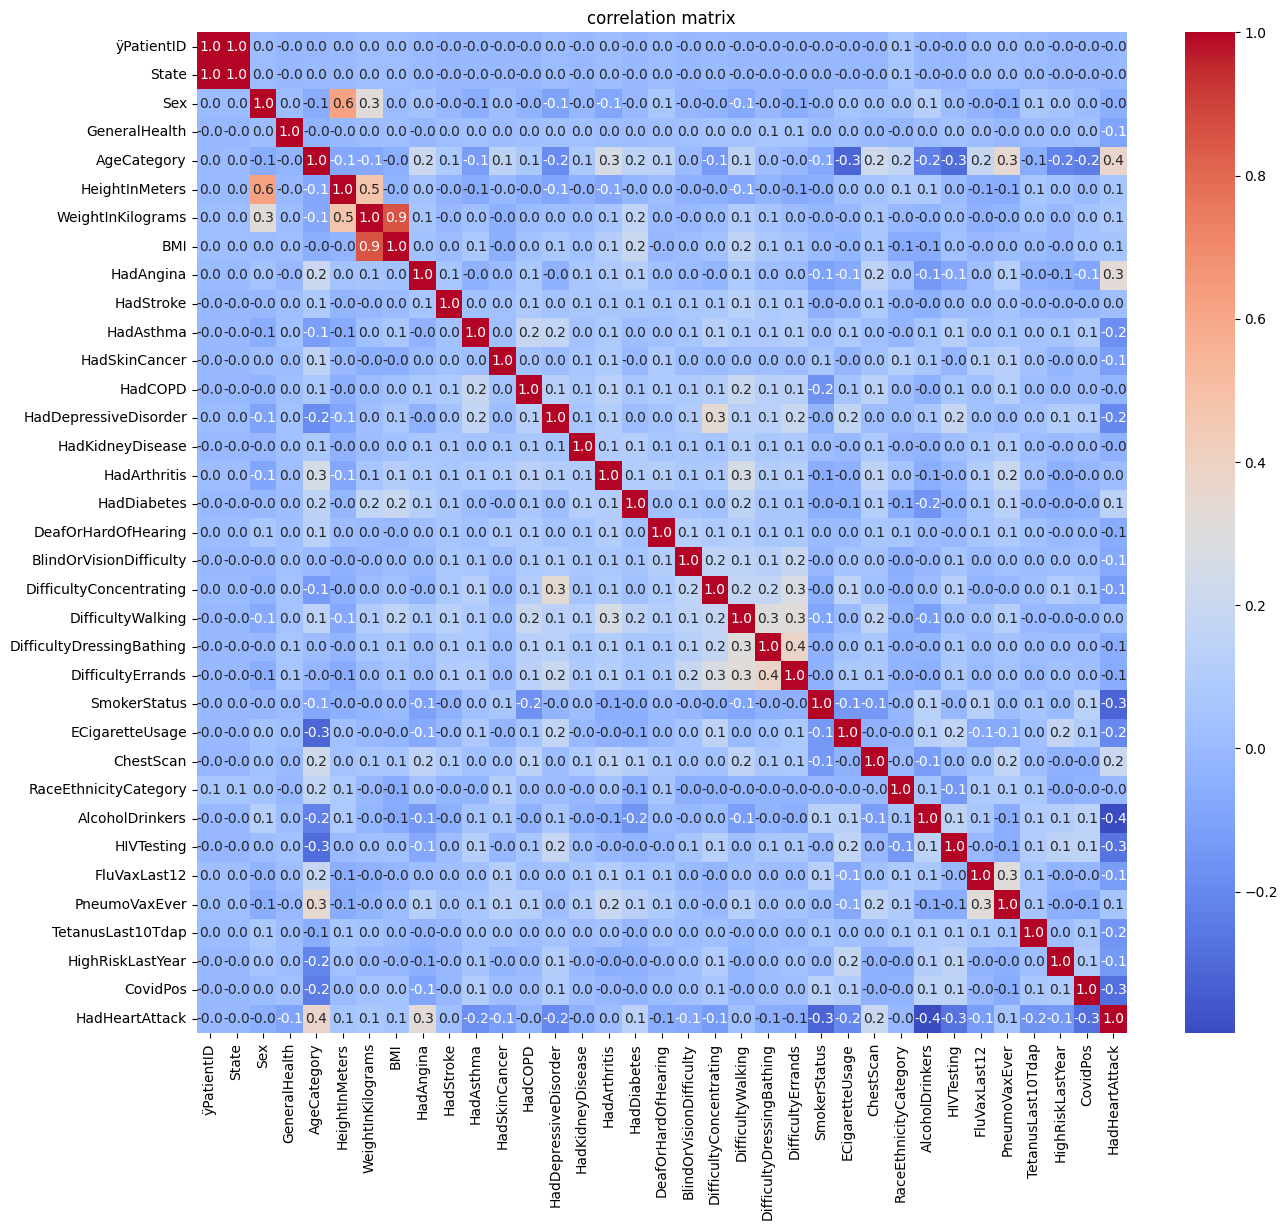

In [ ]:
plt.figure(figsize=(15,13))
corr_matrix = df.corr()

sns.heatmap(corr_matrix,annot=True, fmt='0.01f',cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

In [ ]:
df.drop(["WeightInKilograms","BMI"],axis=1,inplace=True)

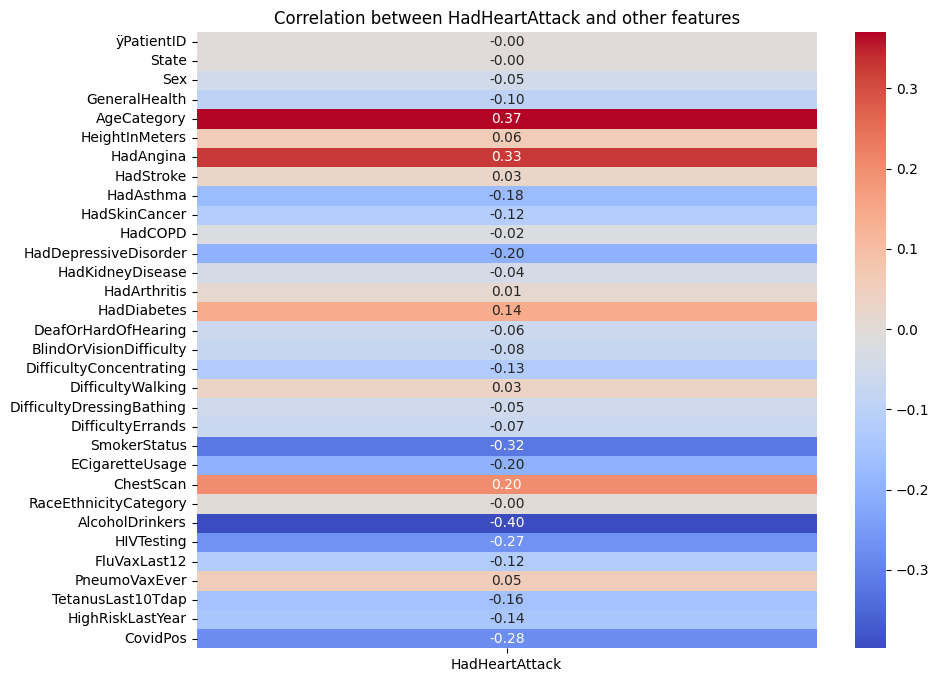

In [ ]:
plt.figure(figsize=(10,8))
HadHeartAttack_corr=df.corr()['HadHeartAttack']
HadHeartAttack_corr=HadHeartAttack_corr.drop('HadHeartAttack')
sns.heatmap(HadHeartAttack_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',cbar=True,annot_kws={'size':10})
plt.title('Correlation between HadHeartAttack and other features')
plt.show()

In [ ]:
df.drop(["ÿPatientID","State","SmokerStatus","ECigaretteUsage","AlcoholDrinkers","HIVTesting","HighRiskLastYear","CovidPos"],axis=1,inplace=True)

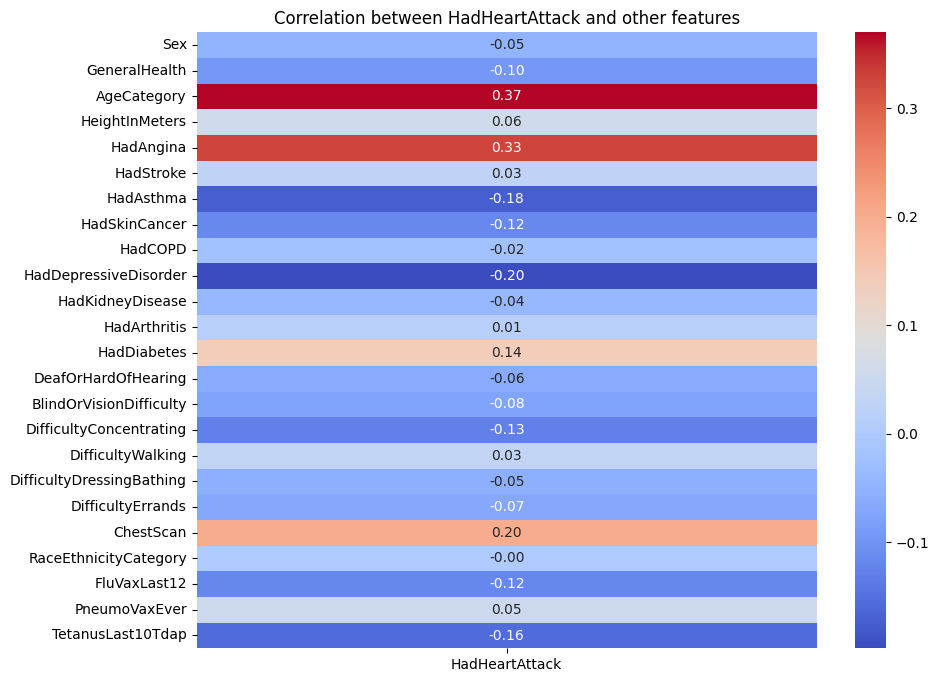

In [ ]:
plt.figure(figsize=(10,8))
loan_status_corr=df.corr()['HadHeartAttack']
loan_status_corr=loan_status_corr.drop('HadHeartAttack')
sns.heatmap(loan_status_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',cbar=True,annot_kws={'size':10})
plt.title('Correlation between HadHeartAttack and other features')
plt.show()

In [ ]:
df.drop(["Sex","HadAsthma","HadSkinCancer","HadDepressiveDisorder","BlindOrVisionDifficulty","DifficultyConcentrating","DifficultyDressingBathing","DifficultyErrands","RaceEthnicityCategory","FluVaxLast12","TetanusLast10Tdap","DeafOrHardOfHearing"],axis=1,inplace=True)

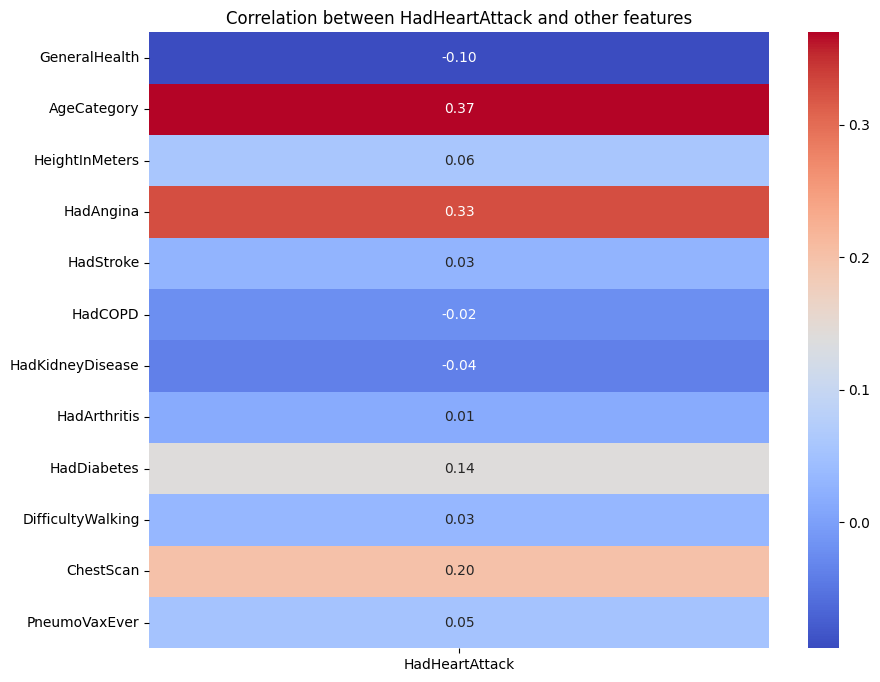

In [ ]:
plt.figure(figsize=(10,8))
loan_status_corr=df.corr()['HadHeartAttack']
loan_status_corr=loan_status_corr.drop('HadHeartAttack')
sns.heatmap(loan_status_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',cbar=True,annot_kws={'size':10})
plt.title('Correlation between HadHeartAttack and other features')
plt.show()

In [ ]:
df.drop(["HeightInMeters","HadStroke","HadCOPD","HadKidneyDisease","HadArthritis","DifficultyWalking"],axis=1,inplace=True)

# outlier checking and removing

<Axes: >

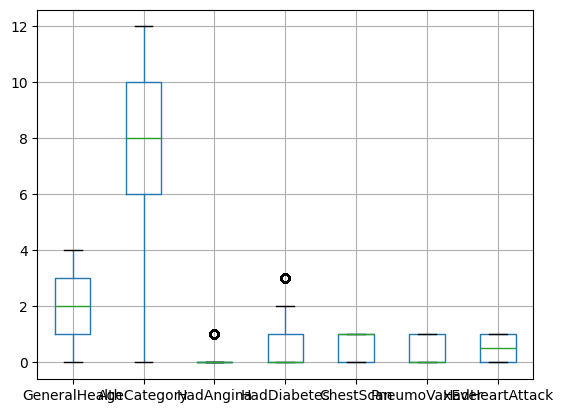

In [ ]:
df.boxplot()

In [ ]:
df.shape

(394042, 7)

# data scaling

In [ ]:
df.head(130)

,GeneralHealth,AgeCategory,HadAngina,HadDiabetes,ChestScan,PneumoVaxEver,HadHeartAttack
0,0,11,1,2,1,1,0
1,1,9,0,0,0,1,0
2,2,8,0,0,0,0,0
3,1,10,0,2,0,1,0
4,3,6,0,0,1,0,0
...,...,...,...,...,...,...,...
125,0,9,0,2,1,1,0
126,4,8,0,0,1,0,1
127,1,9,0,2,0,1,0
128,2,7,0,0,0,0,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd # Import pandas

X = df[['GeneralHealth', 'AgeCategory', 'HadAngina',"HadDiabetes","ChestScan","PneumoVaxEver"]]
y = df['HadHeartAttack']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a baseline logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)


# Predict and evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')





Baseline model accuracy: 0.70


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()
model.fit(X_train, y_train)


# Predict and evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.76


In [ ]:
df

,GeneralHealth,AgeCategory,HadAngina,HadDiabetes,ChestScan,PneumoVaxEver,HadHeartAttack
0,0,11,1,2,1,1,0
1,1,9,0,0,0,1,0
2,2,8,0,0,0,0,0
3,1,10,0,2,0,1,0
4,3,6,0,0,1,0,0
...,...,...,...,...,...,...,...
394037,2,10,0,0,1,0,1
394038,3,5,1,2,0,0,1
394039,1,9,1,0,1,0,1
394040,3,8,1,1,0,0,1


In [ ]:
model.predict([[3	,8,	1	,1	,0,	0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])